### Classification

In **classification**, the goal is to predict a **class label**, which is a choice from a predefined list of possibilities.

In this notebook, we will use the example of  *MNIST* dataset.

Classification is sometimes separated into:

- **Binary classification** — the special case of distinguishing between exactly two classes.  
- **Multiclass classification** — classification between more than two classes.

You can think of binary classification as trying to answer a **yes/no question**.  
For example, classifying emails as either *spam* or *not spam* is a **binary classification** problem.  

In this binary classification task, the yes/no question being asked would be:

> “Is this email spam?”


In binary classification we often speak of one class being the posi‐
tive class and the other class being the negative class. Here, positive
doesn’t represent having benefit or value, but rather what the object
of the study is. So, when looking for spam, “positive” could mean
the spam class. Which of the two classes is called positive is often a
subjective matter, and specific to the domain.

Scikit-Learn provides many helper functions to download popular datasets.  
MNIST is one of them. The following code fetches the MNIST dataset:


In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1,as_frame=False,parser='auto')
mnist.keys()


dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

#### Structure of Scikit-Learn Datasets

Datasets loaded by **Scikit-Learn** includes the following:

- A `DESCR` key describing the dataset  
- A `data` key containing an array with one row per instance and one column per feature  
- A `target` key containing an array with the labels  

Let’s look at these arrays:


In [6]:
X, y = mnist["data"], mnist["target"]
X.shape


(70000, 784)

In [14]:
y.shape


(70000,)

#### Visualizing a Digit from the MNIST Dataset

There are **70,000 images**, and each image has **784 features**.  
This is because each image is **28 × 28 pixels**, and each feature simply represents one pixel’s intensity, from **0 (white)** to **255 (black)**.  

Let’s take a peek at one digit from the dataset.  
All you need to do is grab an instance’s feature vector, reshape it to a 28 × 28 array, and display it using **Matplotlib’s** `imshow()` function:


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()


what it looks like?

In [6]:
y[112]

'1'

Note that the label is a string. Most ML algorithms expect numbers, so let’s cast y to
integer:
 

In [7]:
import numpy as np
y = y.astype(np.uint8)

In [8]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,
               interpolation="nearest")
    plt.axis("off")

In [9]:
# EXTRA
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # This is equivalent to n_rows = ceil(len(instances) / images_per_row):
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Append empty images to fill the end of the grid, if needed:
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # Reshape the array so it's organized as a grid containing 28×28 images:
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Combine axes 0 and 2 (vertical image grid axis, and vertical image axis),
    # and axes 1 and 3 (horizontal axes). We first need to move the axes that we
    # want to combine next to each other, using transpose(), and only then we
    # can reshape:
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    # Now that we have a big image, we just need to show it:
    plt.imshow(big_image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

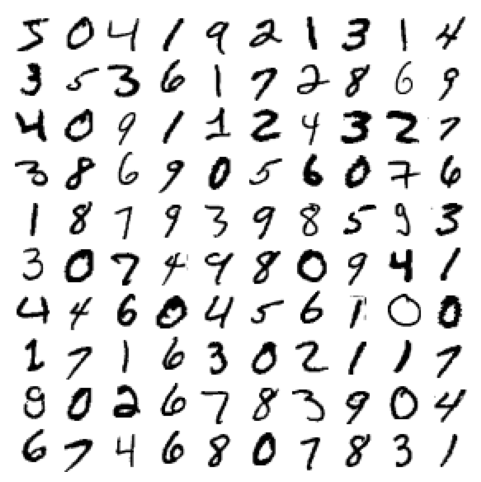

In [19]:
plt.figure(figsize=(6,6))
example_images = X[:100]
plot_digits(example_images, images_per_row=10)
#save_fig("more_digits_plot")
plt.show()

![Digits from the MNIST dataset](mnist.png)

*Figure 1: A sample handwritten digit from the MNIST dataset.*

The MNIST dataset is split into a training set (the first 60,000 
images) and a test set (the last 10,000 images): 


In [10]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

The training set is already shuffled for us, which is good because   
this guarantees that all cross-validation folds will be similar  
(you don’t want one fold to be missing somedigits). Moreover, some learning   
algorithms are sensitive to the order of the training instances, and they perform   
poorly if they get many similar instances in a row. Shuffling the dataset      
ensures that this won’t happen.


Shuffling may be a bad idea in some contexts—for example,   
if you are working on time series data (such as
stock market prices or weather conditions). 

#### Training a Binary Classifier

Let’s simplify the problem for now and only try to identify one digit — for example, the number **5**.  

This *“5-detector”* will be an example of a **binary classifier**, capable of distinguishing between just two classes: **5** and **not-5**.

Let’s create the target vectors for this classification task:


In [11]:
y_train_5 = (y_train == 5)  # True for all 5s, False for all other digits
y_test_5 = (y_test == 5)


In [12]:
y_train_5[:10]

array([ True, False, False, False, False, False, False, False, False,
       False])

In [24]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

Now let’s pick a classifier and train it.  
A good place to start is with a **Stochastic Gradient Descent (SGD)** classifier, using Scikit-Learn’s `SGDClassifier` class.

This classifier has the advantage of being capable of handling **very large datasets efficiently**.  
This is in part because SGD deals with training instances independently, one at a time .

Let’s create an `SGDClassifier` and train it on the whole training set:


In [13]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [26]:
some_digit

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [27]:
sgd_clf.predict([some_digit])

array([ True])

In [28]:
len(y_train_5)

60000

In [29]:
y_train_5[0]

True

The classifier guesses that this image represents a 5 (True). Looks like it guessed right
in this particular case! Now, let’s evaluate this model’s performance.

#### Performance Measures

Evaluating a classifier is often significantly **trickier than evaluating a regressor** 

There are many **performance measures** available


#### Measuring Accuracy Using Cross-Validation

A good way to evaluate a model is to use **cross-validation**

---

#### Implementing Cross-Validation

Occasionally we will need more control over the cross-validation process than what Scikit-Learn provides off the shelf.  
In these cases, you can implement cross-validation yourself. The following code does roughly the same thing as Scikit-Learn’s `cross_val_score()` function, and it prints the same result:


In [30]:
# ------------------------------
# Example: Implementing Stratified K-Fold Cross-Validation
# ------------------------------

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# Create a StratifiedKFold object with 3 folds
# Ensures that each fold has approximately the same ratio of each class
skfolds = StratifiedKFold(n_splits=3,shuffle=True, random_state=42)

# Loop over each fold
for train_index, test_index in skfolds.split(X_train, y_train_5):
    
    # Create a fresh clone of the SGD classifier for this fold
    clone_clf = clone(sgd_clf)
    
    # Split training and test data for this fold
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]
    
    # Train the classifier on the training folds
    clone_clf.fit(X_train_folds, y_train_folds)
    
    # Predict on the test fold
    y_pred = clone_clf.predict(X_test_fold)
    
    # Count number of correct predictions
    n_correct = sum(y_pred == y_test_fold)
    
    # Print accuracy for this fold
    print(n_correct / len(y_pred))  # Accuracy for this fold



0.9669
0.91625
0.96785


The `StratifiedKFold` class performs **stratified sampling** (as explained in Chapter 2)  
to produce folds that contain a representative ratio of each class.  

At each iteration, the code:
1. Creates a **clone** of the classifier.
2. Trains that clone on the training folds.
3. Makes predictions on the test fold.
4. Counts the number of correct predictions and outputs the **ratio of correct predictions**.


#### Cross-Validation and Stratified K-Fold Explained

**1. Cross-Validation (CV):**  
Cross-validation is a technique to evaluate a model’s performance more reliably than using a single train/test split.  
It involves splitting the dataset into multiple subsets (folds), training the model on some folds, and testing it on the remaining fold.  
This process is repeated several times to reduce variance in performance estimates.

**2. K-Fold Validation:**  
- The dataset is divided into **k equal-sized folds**.  
- The model is trained on **k-1 folds** and tested on the remaining fold.  
- This is repeated **k times**, each time with a different fold as the test set.  
- The final performance is averaged over all k iterations.

**3. Stratified K-Fold:**  
- In **classification tasks**, it’s important to maintain the **same class distribution** in each fold as in the full dataset.  
- `StratifiedKFold` does this by performing **stratified sampling**, ensuring that each fold has a representative ratio of each class.

**4. Validation/Test Process:**  
- **Training Set:** Used to train the model.  
- **Validation Set:** Often obtained via cross-validation to tune hyperparameters and estimate performance.  
- **Test Set:** Kept separate to evaluate the final model’s performance.

Cross-validation gives a more **robust estimate** of how the model will perform on unseen data.


Let’s use the cross_val_score() function to evaluate our SGDClassifier model,
using K-fold cross-validation with three folds. Remember that K-fold cross-validation
means splitting the training set into K folds (in this case, three), then making predic‐
tions and evaluating them on each fold using a model trained on the remaining folds



In [14]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")



array([0.95035, 0.96035, 0.9604 ])

Wow! Above 93% accuracy (ratio of correct predictions) on all cross-validation folds?   
This looks amazing, doesn’t it? Well, before you get too excited, let’s look at a very  
dumb classifier that just classifies every single image in the “not-5” class:

#### The "Never-5" Dumb Classifier Example

Sometimes high accuracy can be **misleading**, especially for **imbalanced datasets**.  

Here’s the setup:

- Our task is to detect the digit **5** in MNIST.  
- **Only about 10% of images are 5s**, the rest are "not-5".  
- This means that a classifier that **always predicts "not-5"** will be correct about 90% of the time.  

Let’s look at the code:


In [15]:
from sklearn.base import BaseEstimator
import numpy as np

# Define a very simple classifier that never predicts 5
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        # This classifier doesn't learn anything, so just return itself
        return self
    
    def predict(self, X):
        # Always predict "not-5" (False) for all instances
        return np.zeros((len(X), 1), dtype=bool)


**Explanation of the code:**

1. `Never5Classifier` inherits from `BaseEstimator` so it behaves like a scikit-learn model.
2. `fit` method:
   - Required for scikit-learn API.
   - This classifier does **nothing** during training and just returns itself.
3. `predict` method:
   - For any input `X`, it returns an array of `False` values (same length as `X`).
   - `False` represents "not-5".
4. `np.zeros((len(X),1), dtype=bool)`:
   - Creates a column vector of `False` with the same number of rows as `X`.
   - This is how it always predicts "not-5".


In [33]:
from sklearn.base import BaseEstimator
import numpy as np

# Define a very simple classifier that never predicts 5
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        # This classifier doesn't learn anything, so just return itself
        return self
    
    def predict(self, X):
        # Always predict "not-5" (False) for all instances
        return np.zeros((len(X), 1), dtype=bool)


In [16]:
# Instantiate the classifier
never_5_clf = Never5Classifier()

# Evaluate using 3-fold cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")
print(cv_scores)


[0.91125 0.90855 0.90915]


**Why the accuracy is so high:**

- Accuracy = (number of correct predictions) / (total predictions)
- In this dataset:
  - ~90% of the images are **not 5**.
  - 10% of the images are **5**.
- The `Never5Classifier` always predicts "not-5".
- So it is **correct for all "not-5" images (~90%)**, and wrong for all "5" images (~10%).  
- Result: ~90% accuracy, even though it **does not detect any 5s**.  

**Key takeaway:**  
- Accuracy can be **misleading** on **imbalanced datasets**.  
- You need other performance measures (like **precision, recall, F1-score**) to properly evaluate classifiers in such cases.


**It has over 90% accuracy!**

This is simply because only about 10% of the
images are 5s, so if you always guess that an image is not a 5, you will be right about  
90% of the time. 


This demonstrates why accuracy is generally not the preferred performance measure  
for classifiers, especially when you are dealing with skewed datasets (i.e., when some  
classes are much more frequent than others).

#### Confusion Matrix

A **much better way** to evaluate the performance of a classifier than just using accuracy is to look at the **confusion matrix**.  

**Definition:**  
- A confusion matrix counts the number of times instances of **class A** are classified as **class B**.  
- Example: To see how often images of **5** were confused with **3**, look at the **5th row, 3rd column** of the matrix.

---

#### Getting Predictions Using `cross_val_predict()`

Before computing the confusion matrix, we need predictions for each instance.  
- **Do not use the test set yet**; keep it untouched.  
- Use the **training set** with cross-validation to get “clean” predictions:

```python
from sklearn.model_selection import cross_val_predict

# Predict each instance in training set using 3-fold cross-validation
# Each prediction is made by a model that did NOT see this instance during training
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)


In [17]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Compute confusion matrix
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
conf_mx = confusion_matrix(y_train_5, y_train_pred)
print(conf_mx)


[[53892   687]
 [ 1891  3530]]


In [ ]:
53892  + 687

Each row in a confusion matrix represents an actual class, while each column   
represents a predicted class.   

The first row of this matrix considers non-5 images (the nega‐tive class): 53,892   
of them were correctly classified as non-5s (they are called **true negatives**),  
while the remaining 687 were wrongly classified as 5s (**false positives**).  

The second row considers the images of 5s (the positive class): 1,891 were wrongly    
classified as non-5s (**false negatives**), while the remaining 3,530 were correctly   
classified as 5s (**true positives**). A perfect classifier would have only true positives     
and true negatives, so its confusion matrix would have nonzero values only on its   
main diagonal (top left to bottom right):  

In [36]:
y_train_perfect_predictions = y_train_5 # pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

#### Confusion Matrix – Detailed Explanation

A **confusion matrix** is a table that helps evaluate the performance of a **classification model**, especially for **imbalanced datasets**.  
It shows how many instances of each class were correctly or incorrectly classified.

---

##### Structure of a Confusion Matrix (Binary Classification)

For a **binary classifier** (e.g., 5 vs not-5), the confusion matrix has **2 rows and 2 columns**:

|               | Predicted 5 | Predicted Not-5 |
|---------------|------------|----------------|
| **Actual 5**      | True Positive (TP)  | False Negative (FN) |
| **Actual Not-5**  | False Positive (FP) | True Negative (TN)  |

**Definitions:**

- **True Positive (TP):** Model predicted +, and it really was +. ✅  
- **False Negative (FN):** Model predicted negative, but it actually was positive. ❌  
- **False Positive (FP):** Model predicted positive, but it actually was Negative. ❌  
- **True Negative (TN):** Model predicted Negative, and it really was negative. ✅  

---

##### Why It’s Useful

- Accuracy alone can be **misleading**, especially if classes are imbalanced.  
- The confusion matrix shows **where the model is making mistakes**:
  - Are we missing actual 5s? (high FN)  
  - Are we wrongly predicting 5s? (high FP)  
- From the confusion matrix, we can compute other metrics:
  - **Precision** = TP / (TP + FP) → how many predicted 5s were correct  
  - **Recall** = TP / (TP + FN) → how many actual 5s were detected  
  - **F1-score** = harmonic mean of precision and recall

---

##### Simple Example

Suppose we have 10 predictions:

| Actual     | Predicted  |
|-----------|-----------|
| 5         | 5         |
| 5         | Not-5     |
| Not-5     | Not-5     |
| Not-5     | Not-5     |
| 5         | 5         |
| Not-5     | 5         |
| Not-5     | Not-5     |
| 5         | Not-5     |
| Not-5     | Not-5     |
| Not-5     | Not-5     |

**Step 1:** Count for each category

- TP = 2 (correctly predicted 5s)  
- FN = 2 (5s predicted as Not-5)  
- FP = 1 (Not-5 predicted as 5)  
- TN = 5 (correctly predicted Not-5s)

**Step 2:** Form the confusion matrix



[[TP, FN],
[FP, TN]]

[[2, 2],
[1, 5]]


This gives a **clear picture** of model performance:  
- You can immediately see which type of error is more common.  
- Helps you decide whether to improve the model by **reducing FN or FP**.

**Key Takeaways:**  
1. Confusion matrix is essential for **imbalanced datasets**.  
2. Accuracy can be misleading; the confusion matrix provides **more detailed insights**.  
3. It is the **basis** for precision, recall, and F1-score.


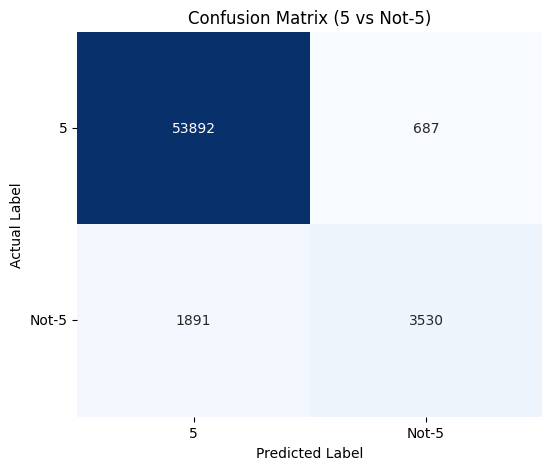

In [37]:
# ------------------------------
# Confusion Matrix Heatmap
# ------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix for SGDClassifier predictions
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
conf_mx = confusion_matrix(y_train_5, y_train_pred)

# Plotting the heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_mx, annot=True, fmt="d", cmap="Blues", cbar=False)

# Labels
plt.title("Confusion Matrix (5 vs Not-5)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0.5, 1.5], ["5", "Not-5"])
plt.yticks([0.5, 1.5], ["5", "Not-5"], rotation=0)

plt.show()


#### Precision and Recall

The confusion matrix gives a lot of information, but sometimes you may prefer a **more concise metric**.  

One interesting metric is the **accuracy of the positive predictions**, called **precision**.

---

##### Precision

Precision measures the proportion of **positive predictions that are actually correct**:

$
Precision = \frac{TP}{TP + FP}
$

Where:  
- **TP** = True Positives (correctly predicted positive instances)  
- **FP** = False Positives (instances incorrectly predicted as positive)

> Note: A trivial way to achieve perfect precision is to make **one positive prediction** and ensure it is correct (precision = 1/1 = 100%).  
> But this is not useful, because the classifier would ignore all other positive instances.

---

##### Recall (Sensitivity / True Positive Rate)

Recall measures the proportion of **actual positive instances that are correctly detected**:

$
\text{Recall} = \frac{TP}{TP + FN}
$

Where:  
- **FN** = False Negatives (positive instances that were missed)  

- Recall tells us **how good the classifier is at detecting all positive instances**.  

---

**Key Point:**  
- **Precision** focuses on **correctness of positive predictions**.  
- **Recall** focuses on **coverage of positive instances**.  
- These metrics are often used together to evaluate classifiers, especially when classes are imbalanced.

---

> If the confusion matrix is confusing, a **diagram can help visualize TP, FP, FN, TN**, showing how precision and recall are computed.


![capt](diagram.png)

Figure 2: An illustrated confusion matrix shows examples of true negatives (top left),
false positives (top right), false negatives (lower left), and true positives (lower right)

#### Precision, Recall, and F1 Score

Scikit-Learn provides functions to compute classifier metrics, including **precision** and **recall**. 
Precision measures the accuracy of positive predictions, while recall measures the proportion of 
actual positives correctly detected. For example, using a 5-detector on the MNIST dataset, we could compute:





In [38]:
from sklearn.metrics import precision_score, recall_score
print( precision_score(y_train_5, y_train_pred) ) # == 4096 / (4096 + 1522)
print( recall_score(y_train_5, y_train_pred) ) # == 4096 / (4096 + 1325)


0.8370879772350012
0.6511713705958311


Now your 5-detector does not look as shiny as it did when you looked at its accuracy.  
When it claims an image represents a 5, it is correct only 72.9% of the time. Moreover, it only detects 75.6% of the 5s.  

It is often convenient to combine precision and recall into a single metric called the F1 score, in particular if you need a simple way to compare two classifiers. The F1 score is the harmonic mean of precision and recall (Equation 3-3). Whereas the regular mean treats all values equally, the harmonic mean gives much more weight to low values. As a result, the classifier will only get a high F1 score if both recall and precision are high.

**F1 score formula:**  

F1 = 2 * (precision * recall) / (precision + recall)  
or equivalently:  
F1 = 2 * TP / (2 * TP + FN + FP)


To compute the F1 score, simply call the f1_score() function:


In [39]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343846

#### Precision/Recall Trade-off

- **F1 score** favors similar precision and recall, but sometimes one matters more than the other.  
- **Example 1:** Detecting safe videos for kids → high **precision** preferred, even if recall is low.  
- **Example 2:** Detecting shoplifters → high **recall** preferred, even if precision is low.  
- **Key point:** Increasing precision usually reduces recall, and vice versa — this is the **precision/recall trade-off**.


The F1 score favors classifiers that have similar precision and recall. 
This is not always what you want: in some contexts you mostly care about precision,  
and in other contexts you really care about recall.    

For example, if you trained a classifier to detect videos that are safe for kids, 
you would probably prefer a classifier that rejects many good videos (low recall)    
but keeps only safe ones (high precision), rather than a classifier that has a much  
higher recall but lets a few really bad videos show up in your product.   
In such cases, you may even want to add a human pipeline to check the   
classifier’s video selection.    

On the other hand, suppose you train a classifier to detect shoplifters in surveillance images: 
it is probably fine if your classifier has only 30% precision as long as it has 99% recall.   
Sure, the security guards will get a few false alerts, but almost all shoplifters will get caught.    

Unfortunately, you can’t have it both ways: increasing precision reduces recall, and vice versa.   
    This is called the **precision/recall trade-off**.


#### Precision/Recall Trade-off and Decision Threshold

- **SGDClassifier** assigns instances based on a **decision score** and a **threshold**.  
- **Threshold effects:**
  - Score > threshold → positive class  
  - Score ≤ threshold → negative class  
- **Example:**  
  - Threshold at center: 4 TP (5s), 1 FP (6) → Precision = 80%, Recall = 67%  
  - Raising threshold: FP → TN, Precision ↑ (100%), but one TP → FN, Recall ↓ (50%)  
  - Lowering threshold: Recall ↑, Precision ↓  
- **Key point:** Adjusting the threshold trades off **precision vs recall**.


#### Adjusting Decision Threshold in SGDClassifier

Scikit-Learn does not let you set the threshold directly, but you can access the **decision scores** used to make predictions.  

Instead of `predict()`, use the classifier's `decision_function()` method to get scores, and then apply any threshold you want:

```python
# Get decision score for a sample digit
y_scores = sgd_clf.decision_function([some_digit])
print(y_scores)  # e.g., array([2412.53175101])

# Default threshold = 0
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)  # array([ True])

# Raise threshold
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)  # array([False])


Observation: Raising the threshold decreases recall.

-The image is actually a 5, detected at threshold 0, but missed at threshold 8000.

-Adjusting the threshold allows control over the precision/recall trade-off.

#### Choosing the Decision Threshold

To decide which threshold to use:

1. Use `cross_val_predict()` to get the **decision scores** for all instances in the training set, instead of predictions:

```python
from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)


With these scores, use precision_recall_curve() to compute precision and recall for all possible thresholds:

In [ ]:
from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)


With these scores, use the precision_recall_curve() function to compute precision
and recall for all possible thresholds:

Finally, use Matplotlib to plot precision and recall as functions of the threshold value



In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16) # Not shown in the book
    plt.xlabel("Threshold", fontsize=16)        # Not shown
    plt.grid(True)                              # Not shown
    plt.axis([-50000, 50000, 0, 1])             # Not shown



recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]


plt.figure(figsize=(8, 4))                                                                  # Not shown
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")                 # Not shown
plt.plot([-50000, threshold_90_precision], [0.9, 0.9], "r:")                                # Not shown
plt.plot([-50000, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")# Not shown
plt.plot([threshold_90_precision], [0.9], "ro")                                             # Not shown
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                             # Not shown
#save_fig("precision_recall_vs_threshold_plot")                                              # Not shown
plt.show()

### Precision and Recall — Detailed Intuition and Examples

---

#### 📘 Definitions
- **Precision** = TP / (TP + FP)  
  → “Out of all the items we predicted as positive, how many are actually positive?”
- **Recall** = TP / (TP + FN)  
  → “Out of all the actual positive items, how many did we successfully detect?”

---

#### 🧠 Intuitive Understanding
- **Precision** measures **trust** in positive predictions.  
  High precision = few false alarms.  
  (Example: spam filter — we don’t want important emails marked as spam.)
- **Recall** measures **coverage** of positives.  
  High recall = few missed positives.  
  (Example: cancer screening — we want to detect every sick person.)

They are often in **conflict**:
- Increasing **threshold** (being stricter) → higher precision, lower recall.  
- Lowering **threshold** (being lenient) → higher recall, lower precision.

---

#### 📊 Simple Example

| Sample | True Label | Predicted |
|---------|-------------|------------|
| 1 | Positive | Positive |
| 2 | Positive | Positive |
| 3 | Positive | Negative |
| 4 | Positive | Negative |
| 5 | Positive | Positive |
| 6 | Negative | Positive |
| 7 | Negative | Negative |
| 8 | Negative | Negative |
| 9 | Negative | Negative |
| 10 | Negative | Negative |

Counting:
- TP = 3, FP = 1, FN = 2, TN = 4  

Then:
- **Precision = 3 / (3 + 1) = 0.75**
- **Recall = 3 / (3 + 2) = 0.60**

Meaning:
- 75% of the predicted positives are correct.
- We detected 60% of the actual positives.

---

#### ⚖️ When Each Metric Matters
| Metric | When Important | Example |
|--------|----------------|---------|
| **Precision** | False positives are costly | Spam filter, fraud detection |
| **Recall** | Missing positives is costly | Medical diagnosis, crime detection |
| **F1-score** | Balance between both | General classification tasks |

---

### 🧩 For **Balanced Datasets**
If your data is **not imbalanced** (roughly equal number of positive and negative samples),  
you can use **accuracy** as a reliable metric.

**Why?**  
When classes are balanced, accuracy reflects the model’s overall correctness well.

**Common metrics for balanced datasets:**
1. **Accuracy** = (TP + TN) / (TP + TN + FP + FN)  
   → Proportion of total correct predictions.
2. **Error rate** = 1 – accuracy  
   → Proportion of total incorrect predictions.
3. **F1-score** (optional)  
   → Still useful if you care about both precision and recall simultaneously.

---

### 🧭 Summary (slide-ready)
- **Precision** → "How correct are our positive predictions?"  
- **Recall** → "How many of the true positives did we find?"  
- **Accuracy** → Best when data is balanced.  
- **F1-score** → Harmonic mean of precision and recall (balances both).  
- **Choose metric** depending on your task’s cost of false positives vs. false negatives.


### 📈 The ROC Curve (Receiver Operating Characteristic)

---

#### 🔍 Concept Overview

The **ROC Curve** is a fundamental tool for evaluating **binary classifiers**.

It is **similar to the Precision-Recall curve**, but instead of plotting **Precision vs Recall**,  
the ROC curve plots:

- **True Positive Rate (TPR)** on the **y-axis** — also called **Recall** or **Sensitivity**
- **False Positive Rate (FPR)** on the **x-axis**

---

#### 🧮 Key Metrics

- **True Positive Rate (TPR)** = TP / (TP + FN)  
  → Measures how many of the actual positives were correctly classified.  
  (Same as **Recall**)

- **False Positive Rate (FPR)** = FP / (FP + TN)  
  → Measures how many of the actual negatives were incorrectly classified as positive.

- **True Negative Rate (TNR)** = TN / (FP + TN)  
  → Also known as **Specificity**

Hence:
> FPR = 1 – TNR

So the ROC curve essentially plots  
**Sensitivity (Recall)** vs **1 – Specificity**.

---

#### ⚙️ How It Works

Each classifier can produce a **decision score** for each instance.  
By adjusting the **decision threshold**, we can change how strict the classifier is:

- Lower threshold → more positives predicted → higher recall but more false positives  
- Higher threshold → fewer positives predicted → higher precision but lower recall  

The ROC curve shows this **trade-off** visually.

---

#### 🎨 Interpretation

- The **diagonal dashed line** (`y = x`) represents a **random classifier** (no skill).
- A **good classifier** stays as far **above** this line as possible (toward the **top-left corner**).
- The **Area Under the Curve (AUC)** summarizes performance:
  - **AUC = 1.0** → perfect classifier  
  - **AUC = 0.5** → random classifier

---

#### 🧭 Summary (slide-ready)
| Term | Meaning | Also Known As |
|------|----------|---------------|
| **TPR** | True Positive Rate | Recall, Sensitivity |
| **FPR** | False Positive Rate | 1 – Specificity |
| **TNR** | True Negative Rate | Specificity |
| **ROC Curve** | TPR vs FPR plot | — |
| **AUC** | Area under ROC curve | Summary metric of model performance |

---



In [ ]:
# 📘 Import the required function
from sklearn.metrics import roc_curve


In [ ]:
# 🧩 Compute ROC Curve values
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)


In [ ]:
# 🎨 Plot ROC Curve
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal for random classifier
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title("ROC Curve")
    plt.grid(True)
    if label:
        plt.legend()

plot_roc_curve(fpr, tpr)
plt.show()


One way to compare classifiers is to measure the area under the curve (AUC). A per‐
fect classifier will have a ROC AUC equal to 1, whereas a purely random classifier will
have a ROC AUC equal to 0.5. Scikit-Learn provides a function to compute the ROC
AUC:


In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)


Since the ROC curve is so similar to the precision/recall (PR)  
curve, you may wonder how to decide which one to use. As a rule  
of thumb, you should prefer the PR curve whenever the positive  
class is rare or when you care more about the false positives than  
the false negatives. Otherwise, use the ROC curve. For example,  
looking at the previous ROC curve (and the ROC AUC score), you   
may think that the classifier is really good. But this is mostly  
because there are few positives (5s) compared to the negatives  
(non-5s). In contrast, the PR curve makes it clear that the classifier  
has room for improvement (the curve could be closer to the top-   
left corner).

### Multiclass Classification

Whereas **binary classifiers** distinguish between two classes, **multiclass classifiers** (also called **multinomial classifiers**) can distinguish between more than two classes.

Some algorithms (such as **SGD classifiers**, **Random Forest classifiers**, and **Naive Bayes classifiers**) can handle multiple classes natively. Others (such as **Logistic Regression** or **Support Vector Machine classifiers**) are strictly binary classifiers. However, there are strategies to perform multiclass classification using multiple binary classifiers.

---

#### One-Versus-the-Rest (OvR)

One way to classify digit images into 10 classes (0–9) is to train **10 binary classifiers**, one for each digit (0-detector, 1-detector, etc.).  
When classifying an image, we take the **decision score from each classifier** and select the class whose classifier outputs the **highest score**.  

This strategy is called **one-versus-the-rest (OvR)**, also known as **one-versus-all**.

---

#### One-Versus-One (OvO)

Another strategy is to train a **binary classifier for every pair of digits**:

- One classifier for 0 vs 1  
- Another for 0 vs 2  
- Another for 1 vs 2  
- And so on...

This is called the **one-versus-one (OvO)** strategy.  

If there are **N classes**, you need to train **N × (N – 1) / 2 classifiers**.  
- For MNIST (10 classes), this means training **45 classifiers**.  
- To classify an image, run it through all 45 classifiers and choose the class that **wins the most duels**.

**Advantage of OvO:** Each classifier only needs to be trained on the subset of the training set for the two classes it distinguishes.  

- Some algorithms (e.g., SVMs) scale poorly with large training sets.  
  - OvO is preferred because training many classifiers on small datasets is faster than training few classifiers on large datasets.  
- For most binary classification algorithms, **OvR is preferred**.


Scikit-Learn detects when you try to use a binary classification algorithm for a multiclass classification task,  
and it automatically runs OvR or OvO, depending on the algorithm.  

Let’s try this with a Support Vector Machine classifier (see Chapter 5), using the `sklearn.svm.SVC` class.  

This code trains the SVC on the training set using the **original target classes** from 0 to 9 (`y_train`),  
instead of the 5-versus-the-rest target classes (`y_train_5`). Then it makes a prediction (a correct one in this case).  

Under the hood, Scikit-Learn actually used the **OvO strategy**:  
- It trained 45 binary classifiers  
- Got their decision scores for the image  
- Selected the class that won the most duels  

If you call the `decision_function()` method, you will see that it returns **10 scores per instance** (instead of just 1).  
That’s one score per class.


In [ ]:
from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(X_train, y_train)  # y_train, not y_train_5
some_digit = X[0]
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores



The highest score corresponds to the class 5:

You can check which class has the maximum decision score using `np.argmax()`,  
and inspect the classifier's `classes_` attribute to see the mapping of indices to class labels.


In [ ]:
np.argmax(some_digit_scores)
# Output: 5
svm_clf.classes_
svm_clf.classes_[5]
# Output: 5


If you want to force Scikit-Learn to use one-versus-one or one-versus-the-rest, you
can use the OneVsOneClassifier or OneVsRestClassifier classes. Simply create an
instance and pass a classifier to its constructor (it does not even have to be a binary
classifier). For example, this code creates a multiclass classifier using the OvR strat‐
egy, based on an SVC:


In [ ]:
>>> from sklearn.multiclass import OneVsRestClassifier
>>> ovr_clf = OneVsRestClassifier(SVC())
>>> ovr_clf.fit(X_train, y_train)

# Multilabel Classification

Until now each instance has always been assigned to just one class.  
In some cases you may want your classifier to output **multiple classes for each instance**.  

Example: Face-recognition classifier  
- If the classifier recognizes several people in the same picture, it should attach **one tag per person**.  
- Suppose it recognizes Alice, Bob, and Charlie.  
- If the picture contains Alice and Charlie, the output should be `[1, 0, 1]` (Alice yes, Bob no, Charlie yes).  

Such a classification system is called a **multilabel classification system**.


In [19]:
# Example from the original text
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)



KNeighborsClassifier()

In [2]:
knn_clf.predict([some_digit])
array([[False, True]])


NameError: name 'knn_clf' is not defined

- The prediction is correct: the digit 5 is **not large** (False) and **odd** (True).  
- Many ways exist to evaluate a multilabel classifier.  

Example evaluation: compute **F1 score for each label** and take the average.

```python
>>> from sklearn.model_selection import cross_val_predict
>>> from sklearn.metrics import f1_score

>>> y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
>>> f1_score(y_multilabel, y_train_knn_pred, average="macro")
0.976410265560605



---

### Detailed Explanation (Simplified & Additional Examples)

```markdown
# Multilabel Classification — Intuition

- **Multilabel classification** = multiple binary classification tasks combined.
- Each instance can belong to **more than one class simultaneously**.
- Examples:
  - Tagging a news article with multiple topics (politics, sports, economy)
  - Predicting attributes of a product (color, size, category)
  - Detecting multiple diseases in medical images
  - Face recognition in a group photo

---

# Simple Example Table

| Image | Large? | Odd? |
|-------|--------|------|
| 5     | False  | True |
| 8     | True   | False |
| 7     | True   | True |

- Classifier predicts **both labels at once**.
- Evaluate **per label** and then **average**.
- Can handle imbalanced labels using weighted F1.

---

# Key Points

1. Multilabel = multiple independent or joint binary outputs  
2. Not all classifiers support multilabel natively (KNN, RandomForest, etc., do)  
3. Metrics like **F1, precision, recall** can be adapted for multilabel  
4. `average="macro"` treats all labels equally  
5. `average="weighted"` accounts for label imbalance


# Multioutput Classification

The last type of classification task is **multioutput–multiclass classification**  
(or simply **multioutput classification**).  

It is a generalization of **multilabel classification** where **each label can be multiclass**  
(i.e., it can have more than two possible values).

---

## Example: Image Denoising

- Input: a **noisy digit image**  
- Output: a **clean digit image**, represented as an array of pixel intensities (0–255)  
- Notes:
  - The output is **multilabel** (one label per pixel)  
  - Each label can have **multiple values** → multioutput system  
  - Predicting pixel intensities is **similar to regression**  
  - Multioutput systems are not limited to classification; outputs can be a mix of **class and value labels**

---

## Create Training and Test Sets with Noise

- Add noise to MNIST images using NumPy:

```python
import numpy as np

# Add noise to training images
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise

# Add noise to test images
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise

# Targets are the original images
y_train_mod = X_train
y_test_mod = X_test
